# Advisor review — empirical visualization

Visualizes the four advisor-feedback follow-up experiments living under
`results/advisor_review/`. Built incrementally — each section corresponds
to one Step in the worker plan and is gated on those CSVs existing on
disk, so this notebook is safe to re-run at any stage of the experiments.

Sections
1. **Setup** — paths, loaders, styling.
2. **HP tuning summary** — Pareto scatters per HP sweep step.
3. **Hypothesis 3a: DP vs AP** (healthcare).
4. **Hypothesis 3b: benefit vs cost imbalance** (MD).
5. **Hypothesis 3c: train vs test gap** (healthcare).
6. **Budget tightness sweep** (MD + healthcare side by side).
7. **Takeaways**.

## 1. Setup

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path('..').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from experiments.configs import COLOR_MAP, MARKER_MAP

ADV = REPO_ROOT / 'results' / 'advisor_review'
FIGS = ADV / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)

print('repo root:', REPO_ROOT)
print('advisor results dir:', ADV)
print('exists:', ADV.exists())

repo root: E:\Codes\DecisionFocusedMTL
advisor results dir: E:\Codes\DecisionFocusedMTL\results\advisor_review
exists: True


In [2]:
def load_run(run_dir: Path) -> tuple[pd.DataFrame, dict]:
    """Load (stage_df, config_payload) from a single advisor_review run dir."""
    run_dir = Path(run_dir)
    stage_csv = run_dir / 'stage_results.csv'
    cfg_json = run_dir / 'config.json'
    if not stage_csv.exists():
        return pd.DataFrame(), {}
    df = pd.read_csv(stage_csv)
    cfg = json.loads(cfg_json.read_text()) if cfg_json.exists() else {}
    df['_source_dir'] = str(run_dir.relative_to(ADV))
    return df, cfg


def load_many(parent: Path, glob: str = '*') -> pd.DataFrame:
    """Concatenate stage_results.csv across all subdirectories matching `glob`."""
    dfs = []
    for sub in sorted(Path(parent).glob(glob)):
        if not sub.is_dir():
            continue
        df, _ = load_run(sub)
        if not df.empty:
            df['_subdir'] = sub.name
            dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()


def style_for(method: str) -> dict:
    return {
        'color': COLOR_MAP.get(method, '#888888'),
        'marker': MARKER_MAP.get(method, 'o'),
    }


def savefig(fig: plt.Figure, name: str, dpi: int = 130) -> Path:
    out = FIGS / name
    fig.savefig(out, dpi=dpi, bbox_inches='tight')
    print('  saved', out)
    return out

In [3]:
# Smoke-test the loader on the existing smoke_test run.
smoke = ADV / 'hp_tuning' / 'md_knapsack' / 'smoke_test'
df_smoke, cfg_smoke = load_run(smoke)
print('smoke rows:', len(df_smoke))
if len(df_smoke):
    cols = ['method', 'lambda', 'train_regret', 'test_regret',
            'train_pred_mse', 'test_pred_mse', 'train_fairness', 'test_fairness']
    print(df_smoke[cols].to_string(index=False))

smoke rows: 2
method  lambda  train_regret  test_regret  train_pred_mse  test_pred_mse  train_fairness  test_fairness
  fpto     0.0    429.317887   167.986787        4.242714       3.860375        0.085232       1.735677
   dfl     0.0    244.644849   116.251382        4.091484       3.828516        0.103539       1.797463


C:\Users\14469\AppData\Local\Temp\ipykernel_26528\3797103930.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['_source_dir'] = str(run_dir.relative_to(ADV))


## 2. HP tuning summary (Step 2)

One Pareto scatter per sweep stage. The goal of HP tuning is to find a
configuration where method families *separate*: PTO/SAA cluster at low
MSE / high regret, DFL/FDFL at higher MSE / lower regret, MOO methods
in between. We are NOT minimising any single number.

This cell is gated — it only runs once the HP sweep dirs exist.

In [4]:
hp_root = ADV / 'hp_tuning' / 'md_knapsack'
hp_subdirs = [p for p in sorted(hp_root.iterdir()) if p.is_dir() and p.name != 'figures']
print('HP sweep stages found:', [p.name for p in hp_subdirs])

HP sweep stages found: ['smoke_test']


  saved E:\Codes\DecisionFocusedMTL\results\advisor_review\figures\hp_sweep_pareto_overview.png


C:\Users\14469\AppData\Local\Temp\ipykernel_26528\3797103930.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['_source_dir'] = str(run_dir.relative_to(ADV))


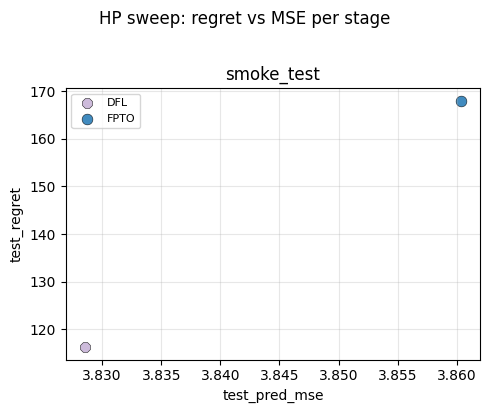

In [5]:
def pareto_scatter(df: pd.DataFrame, ax: plt.Axes, x: str, y: str, title: str = '') -> None:
    if df.empty or x not in df or y not in df:
        ax.text(0.5, 0.5, '(no data)', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        return
    for method, sub in df.groupby('method'):
        s = style_for(str(method).upper())
        ax.scatter(sub[x], sub[y], label=str(method).upper(), **s, s=60, alpha=0.85, edgecolor='black', linewidth=0.4)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)


if hp_subdirs:
    n = len(hp_subdirs)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), squeeze=False)
    for ax, sub in zip(axes[0], hp_subdirs):
        df, _ = load_run(sub)
        pareto_scatter(df, ax, x='test_pred_mse', y='test_regret', title=sub.name)
    axes[0, 0].legend(loc='best', fontsize=8)
    fig.suptitle('HP sweep: regret vs MSE per stage', y=1.02)
    fig.tight_layout()
    savefig(fig, 'hp_sweep_pareto_overview.png')
    plt.show()
else:
    print('(no HP sweep dirs yet — run Step 2)')

## 3. Hypothesis 3a — Demographic parity vs Accuracy parity (healthcare)

Side-by-side Pareto plots: regret-vs-fairness for `mad` (accuracy parity)
and `dp` (demographic parity). One panel per alpha.

In [6]:
ap_root = ADV / 'hypothesis' / 'dp_vs_ap' / 'ap'
dp_root = ADV / 'hypothesis' / 'dp_vs_ap' / 'dp'
df_ap = load_many(ap_root) if ap_root.exists() else pd.DataFrame()
df_dp = load_many(dp_root) if dp_root.exists() else pd.DataFrame()
print('AP rows:', len(df_ap), '  DP rows:', len(df_dp))

AP rows: 0   DP rows: 0


In [7]:
def overlay_pareto(df_a: pd.DataFrame, df_b: pd.DataFrame, label_a: str, label_b: str,
                   x: str, y: str, alpha: float, ax: plt.Axes) -> None:
    for df, label, marker_offset in ((df_a, label_a, 0), (df_b, label_b, 1)):
        if df.empty or 'alpha_fair' not in df:
            continue
        sub = df[df.get('alpha_fair', alpha) == alpha]
        for method, mdf in sub.groupby('method'):
            s = style_for(str(method).upper())
            mk = s['marker'] if marker_offset == 0 else 'x'
            ax.scatter(mdf[x], mdf[y], color=s['color'], marker=mk,
                       label=f"{method.upper()} ({label})",
                       s=70, alpha=0.85, edgecolor='black', linewidth=0.3)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f'alpha={alpha}')
    ax.grid(True, alpha=0.3)


if not df_ap.empty or not df_dp.empty:
    alphas = sorted(set(df_ap.get('alpha_fair', [])).union(df_dp.get('alpha_fair', [])))
    if alphas:
        fig, axes = plt.subplots(1, len(alphas), figsize=(6 * len(alphas), 4), squeeze=False)
        for ax, a in zip(axes[0], alphas):
            overlay_pareto(df_ap, df_dp, 'AP', 'DP', x='test_fairness', y='test_regret', alpha=a, ax=ax)
        axes[0, 0].legend(fontsize=7, loc='best')
        fig.suptitle('DP vs AP: regret vs (test) fairness', y=1.02)
        fig.tight_layout()
        savefig(fig, 'pareto_dp_vs_ap_regret_vs_fairness.png')
        plt.show()
else:
    print('(no DP/AP runs yet — run Step 3a)')

(no DP/AP runs yet — run Step 3a)


## 4. Hypothesis 3b — Benefit vs cost imbalance (MD)

3×3 grid of `(benefit_group_bias, cost_group_bias)` cells.
Render two heatmaps per method: test_regret and test_fairness.

In [8]:
bc_root = ADV / 'hypothesis' / 'benefit_cost_imbalance'
bc_dirs = sorted([p for p in bc_root.iterdir() if p.is_dir()]) if bc_root.exists() else []
print('benefit/cost cells found:', len(bc_dirs))

benefit/cost cells found: 0


In [9]:
if bc_dirs:
    rows = []
    for d in bc_dirs:
        df, cfg = load_run(d)
        if df.empty:
            continue
        bb = cfg.get('task_cfg', {}).get('benefit_group_bias', None)
        cb = cfg.get('task_cfg', {}).get('cost_group_bias', None)
        df['_bb'] = bb
        df['_cb'] = cb
        rows.append(df)
    grid_df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    if not grid_df.empty:
        for metric in ('test_regret', 'test_fairness'):
            methods = sorted(grid_df['method'].unique())
            n = len(methods)
            fig, axes = plt.subplots(1, n, figsize=(3.5 * n, 3.2), squeeze=False)
            for ax, m in zip(axes[0], methods):
                pivot = (grid_df[grid_df['method'] == m]
                         .groupby(['_bb', '_cb'])[metric].mean().unstack('_cb'))
                im = ax.imshow(pivot.values, aspect='auto', origin='lower', cmap='viridis')
                ax.set_xticks(range(len(pivot.columns)))
                ax.set_xticklabels(pivot.columns)
                ax.set_yticks(range(len(pivot.index)))
                ax.set_yticklabels(pivot.index)
                ax.set_xlabel('cost_group_bias')
                ax.set_ylabel('benefit_group_bias')
                ax.set_title(f'{m} — {metric}')
                fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            fig.tight_layout()
            savefig(fig, f'imbalance_grid_{metric}.png')
            plt.show()
else:
    print('(no benefit/cost imbalance runs yet — run Step 3b)')

(no benefit/cost imbalance runs yet — run Step 3b)


## 5. Hypothesis 3c — Train vs test gap (healthcare)

Reuses the DP/AP CSVs from Step 3a. Bar chart of mean (train_regret -
test_regret) per method, plus a scatter.

In [10]:
if not df_ap.empty:
    work = df_ap.copy()
    work['regret_gap'] = work['train_regret'] - work['test_regret']
    work['mse_gap'] = work['train_pred_mse'] - work['test_pred_mse']
    work['fair_gap'] = work['train_fairness'] - work['test_fairness']
    summary = (work.groupby('method')[['regret_gap', 'mse_gap', 'fair_gap']]
               .mean().round(4))
    print('Mean train-test gap by method (AP healthcare runs):')
    print(summary.to_string())

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    summary['regret_gap'].plot(kind='bar', ax=axes[0],
                                color=[COLOR_MAP.get(m.upper(), '#888') for m in summary.index])
    axes[0].set_title('Train - Test regret gap')
    axes[0].axhline(0, color='black', lw=0.6)
    axes[0].grid(True, alpha=0.3)

    for method, sub in work.groupby('method'):
        s = style_for(str(method).upper())
        axes[1].scatter(sub['train_regret'], sub['test_regret'],
                        label=str(method).upper(), s=60, alpha=0.8, **s)
    lo = min(work['train_regret'].min(), work['test_regret'].min())
    hi = max(work['train_regret'].max(), work['test_regret'].max())
    axes[1].plot([lo, hi], [lo, hi], color='gray', lw=0.6)
    axes[1].set_xlabel('train_regret')
    axes[1].set_ylabel('test_regret')
    axes[1].set_title('Train vs Test regret per run')
    axes[1].legend(fontsize=7)
    axes[1].grid(True, alpha=0.3)
    fig.tight_layout()
    savefig(fig, 'train_test_gap.png')
    plt.show()
else:
    print('(no healthcare AP runs yet — run Step 3a first)')

(no healthcare AP runs yet — run Step 3a first)


## 6. Budget tightness sweep (Step 4)

Side-by-side: small MD (4a) and local-scale healthcare (4b).

In [11]:
def collect_budget(parent: Path, knob: str) -> pd.DataFrame:
    if not parent.exists():
        return pd.DataFrame()
    rows = []
    for sub in sorted(parent.iterdir()):
        if not sub.is_dir():
            continue
        df, cfg = load_run(sub)
        if df.empty:
            continue
        df['_budget'] = cfg.get('task_cfg', {}).get(knob, np.nan)
        rows.append(df)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


df_md_b = collect_budget(ADV / 'budget_sweep' / 'md_small', 'budget_tightness')
df_hc_b = collect_budget(ADV / 'budget_sweep' / 'healthcare_full', 'budget_rho')
print('MD budget rows:', len(df_md_b), '  HC budget rows:', len(df_hc_b))

MD budget rows: 0   HC budget rows: 0


In [12]:
def budget_lineplot(df: pd.DataFrame, title: str, ax: plt.Axes) -> None:
    if df.empty:
        ax.text(0.5, 0.5, '(no data)', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        return
    g = df.groupby(['method', '_budget'])['test_regret'].mean().reset_index()
    for method, sub in g.groupby('method'):
        sub = sub.sort_values('_budget')
        s = style_for(str(method).upper())
        ax.plot(sub['_budget'], sub['test_regret'], '-o',
                label=str(method).upper(), color=s['color'], marker=s['marker'])
    ax.set_xlabel('budget')
    ax.set_ylabel('mean test_regret')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)


if not (df_md_b.empty and df_hc_b.empty):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    budget_lineplot(df_md_b, 'MD knapsack', axes[0])
    budget_lineplot(df_hc_b, 'Healthcare (n=5000)', axes[1])
    axes[0].legend(fontsize=7)
    fig.tight_layout()
    savefig(fig, 'budget_sweep.png')
    plt.show()
else:
    print('(no budget sweep runs yet — run Step 4)')

(no budget sweep runs yet — run Step 4)


## 7. Takeaways

_To be filled in once experiments are complete. Each subsection should
be one short paragraph: what we expected, what we observed, and whether
the paper claim is supported._

1. **DP vs AP fairness on healthcare** — TODO
2. **Benefit vs cost imbalance separation on MD** — TODO
3. **Train/test gap by method** — TODO
4. **Budget tightness regime** — TODO